In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates



In [2]:
# Load the COVID-19 worldmeter dataset
df = pd.read_csv('worldometer_coronavirus_daily_data.csv')
df.head(5)

,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
0,2020-2-15,Afghanistan,0.0,NaN,0.0,0.0,NaN
1,2020-2-16,Afghanistan,0.0,NaN,0.0,0.0,NaN
2,2020-2-17,Afghanistan,0.0,NaN,0.0,0.0,NaN
3,2020-2-18,Afghanistan,0.0,NaN,0.0,0.0,NaN
4,2020-2-19,Afghanistan,0.0,NaN,0.0,0.0,NaN


In [3]:
# Compute daily cases 
df_daily = df['daily_new_cases']
#print(df_daily.info())
# print(df_daily.describe())
print(df_daily.notnull().sum().sum())
print(df_daily.isnull().sum().sum())

174329
10458


In [44]:
# compute and visualize country wise daily case
#===============================

df_daily_trends = df.groupby('date')['daily_new_cases'].sum().reset_index()
# df_daily_trends = df_daily_trends.sort_values(by='daily_new_cases', ascending=False).head(10)
print(df_daily_trends)


# Select the country to see the date wise daily cases
country = 'India'

print(f"Daily new cases in {country}:")

df_country_daily = (
    df[df['country'] == country]
    [['daily_new_cases']]
    .reset_index()
)

print(df_country_daily)

          date  daily_new_cases
0   2020-01-22              0.0
1   2020-01-23            259.0
2   2020-01-24            457.0
3   2020-01-25            688.0
4   2020-01-26            769.0
..         ...              ...
839 2022-05-10         650042.0
840 2022-05-11         649201.0
841 2022-05-12         666242.0
842 2022-05-13         565646.0
843 2022-05-14         414583.0

[844 rows x 2 columns]
Daily new cases in India:
          date  daily_new_cases
0   2020-02-15              NaN
1   2020-02-16              0.0
2   2020-02-17              0.0
3   2020-02-18              0.0
4   2020-02-19              0.0
..         ...              ...
815 2022-05-10           2897.0
816 2022-05-11           2827.0
817 2022-05-12           3187.0
818 2022-05-13           2512.0
819 2022-05-14           2487.0

[820 rows x 2 columns]


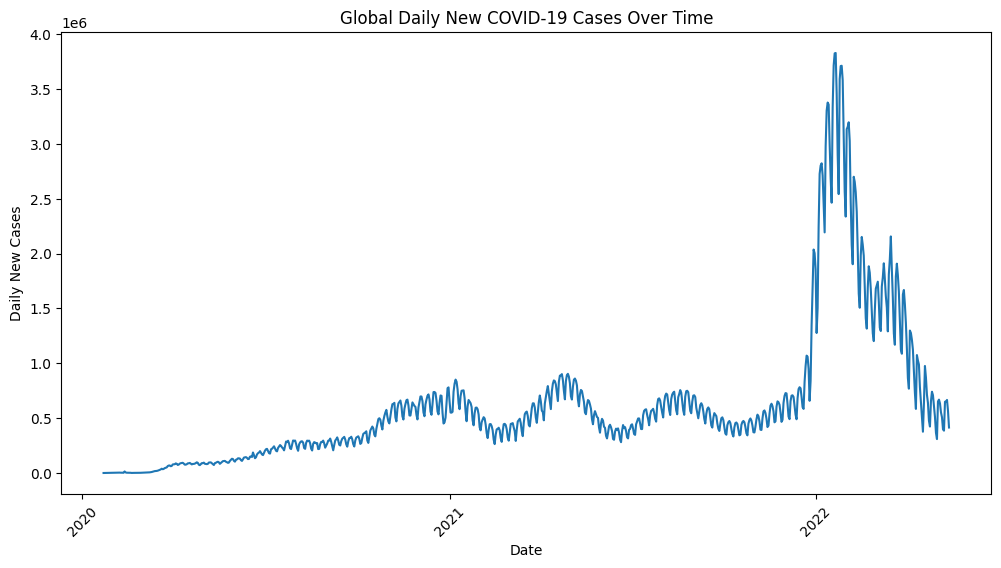

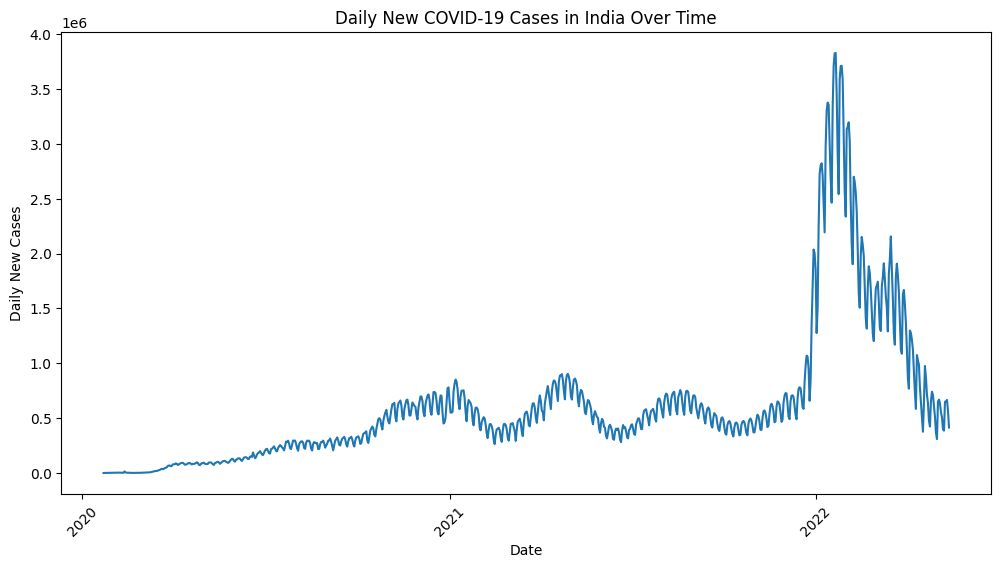

In [45]:
#plot the global daily cases date wise trend 
#================================================

df.index = pd.to_datetime(df.index)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_daily_trends, x='date', y='daily_new_cases')
plt.title('Global Daily New COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Daily New Cases')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.savefig('global_daily_cases_trend.png')
plt.show()



#plot the country wise daily cases date wise trend
#================================================


plt.figure(figsize=(12, 6))
sns.lineplot(data=df_daily_trends, x='date', y='daily_new_cases')
plt.title(f'Daily New COVID-19 Cases in {country} Over Time')
plt.xlabel('Date')
plt.ylabel('Daily New Cases')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.savefig('daily_cases_trend_country_wise.png')
plt.show()


        date  daily_new_cases
0 2020-01-26           2173.0
1 2020-02-02          14461.0
2 2020-02-09          22966.0
3 2020-02-16          30417.0
4 2020-02-23           7862.0
    week_label  daily_new_cases
0       Week 1           2173.0
1       Week 2          14461.0
2       Week 3          22966.0
3       Week 4          30417.0
4       Week 5           7862.0
..         ...              ...
116   Week 117        5636188.0
117   Week 118        4687089.0
118   Week 119        4016818.0
119   Week 120        3722271.0
120   Week 121        3331547.0

[121 rows x 2 columns]


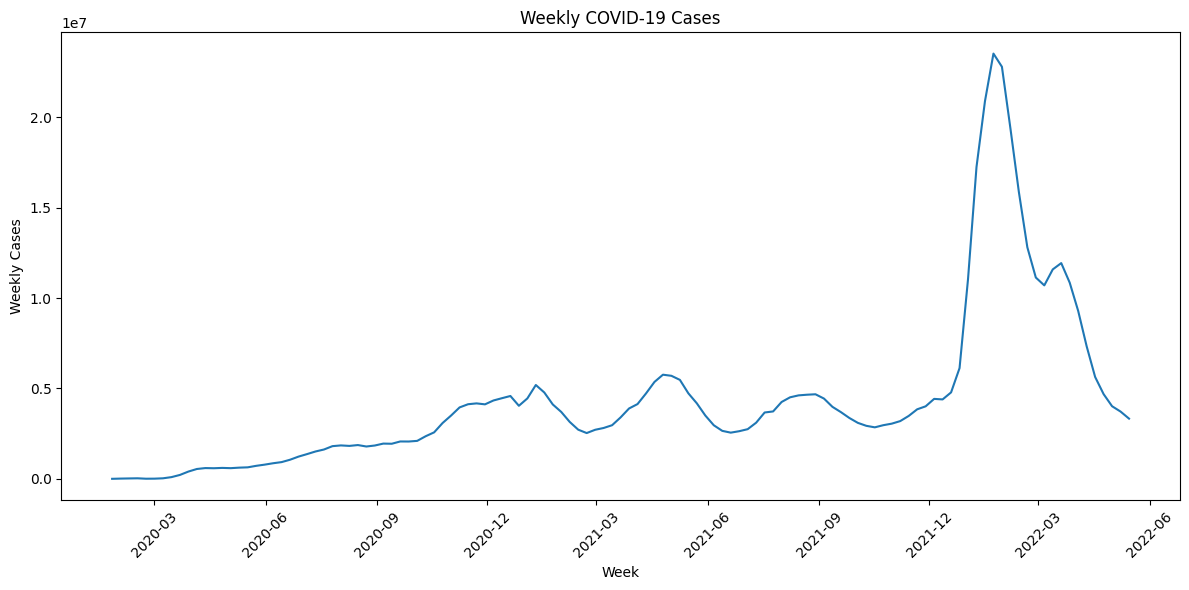

In [46]:
# Compute weekly cases
#=============================


# Convert index to datetime
df.index = pd.to_datetime(df.index)

df_weekly = (
    df.resample('W')['daily_new_cases']
    .sum()
    .reset_index()
)

print(df_weekly.head())

# 3. Add clean sequential week labels (e.g., "Week 1", "Week 2")
df_weekly['week_label'] = "Week " + (df_weekly.index + 1).astype(str)

# 3. Print the result
print(df_weekly[['week_label', 'daily_new_cases']])




plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_weekly,
    x='date',
    y='daily_new_cases'
)

plt.title('Weekly COVID-19 Cases')
plt.xlabel('Week')
plt.ylabel('Weekly Cases')

# Show fewer labels (every 3 months)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('weekly_cases_trend.png' ,bbox_inches='tight',dpi = 300)
plt.show()


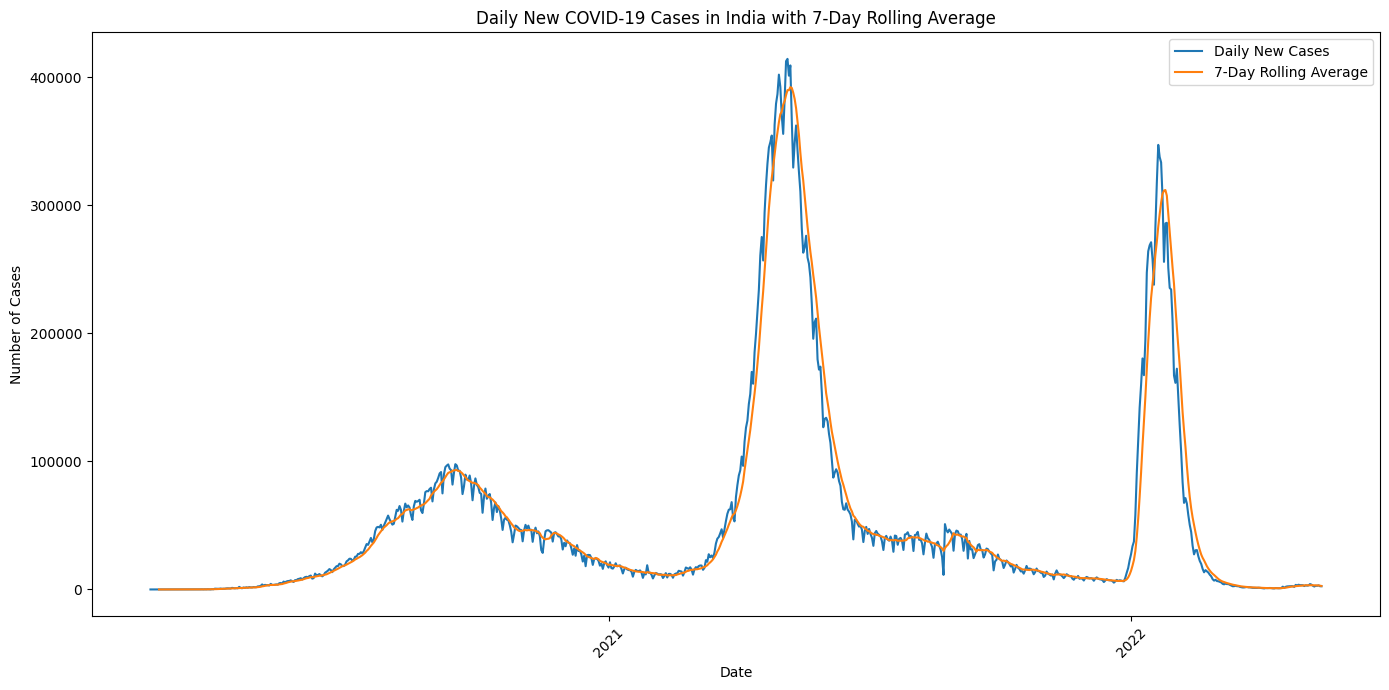

In [47]:
# country wise comparison of daily cases and rolling averages to smooth noise
#=============================================================================

df_country_daily['date'] = pd.to_datetime(
    df_country_daily['date']
)


plt.figure(figsize=(14,7))
sns.lineplot(data=df_country_daily, x='date', y='daily_new_cases', label='Daily New Cases')

# Calculate and plot the 7-day rolling average
df_country_daily['7_day_avg'] = df_country_daily['daily_new_cases'].rolling(window=7).mean()
sns.lineplot(data=df_country_daily, x='date', y='7_day_avg', label='7-Day Rolling Average')
plt.title(f'Daily New COVID-19 Cases in {country} with 7-Day Rolling Average')

plt.xlabel('Date')
plt.ylabel('Number of Cases')

plt.gca().xaxis.set_major_locator(
    mdates.YearLocator()
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('daily_cases_with_rolling_avg.png', bbox_inches='tight', dpi=300)
plt.show()

Peak daily new cases in India: 414433.0 on 2021-05-06 00:00:00


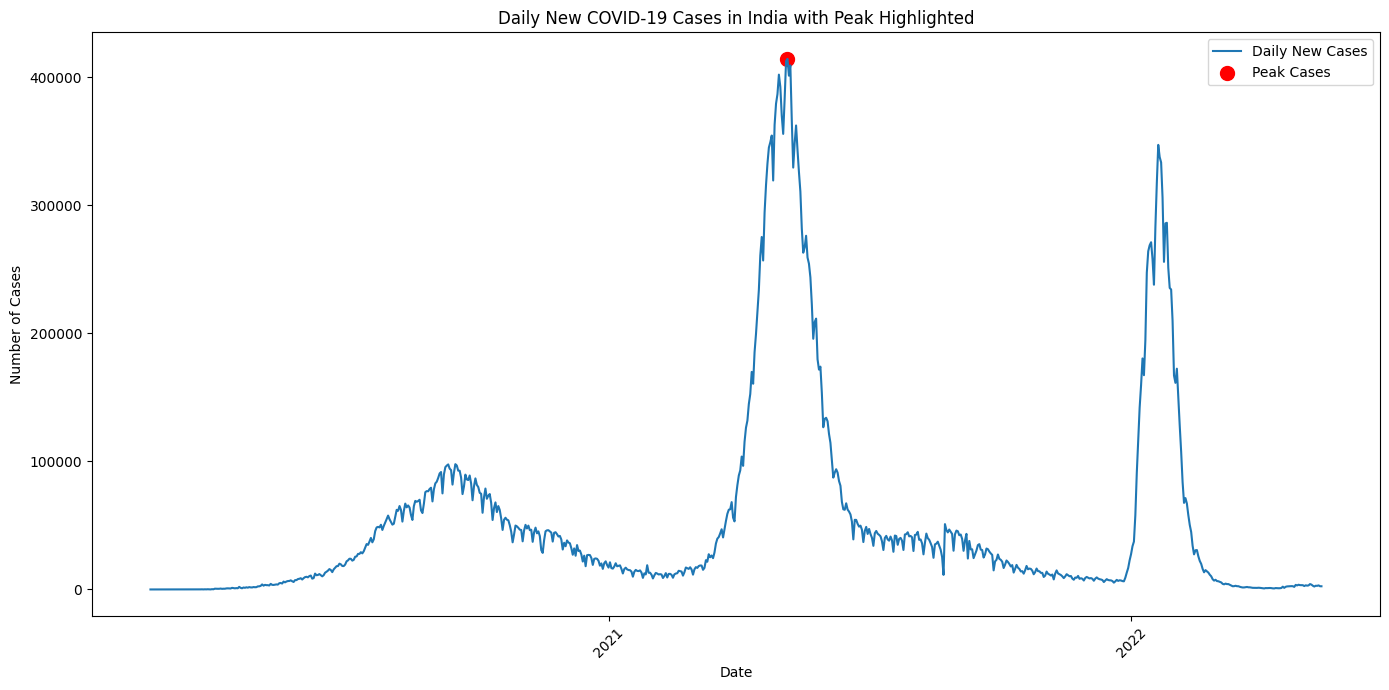

In [48]:
#Detect peaks with a particular date
#================================

peak_case = df_country_daily.loc[
    df_country_daily['daily_new_cases'].idxmax()
]

print(
    f"Peak daily new cases in {country}: "
    f"{peak_case['daily_new_cases']} "
    f"on {peak_case['date']}"
)

plt.figure(figsize=(14,7))
sns.lineplot(data=df_country_daily, x='date', y='daily_new_cases', label='Daily New Cases')
plt.scatter(
    peak_case['date'],
    peak_case['daily_new_cases'],
    color='red',
    label='Peak Cases',
    s=100
)
plt.title(f'Daily New COVID-19 Cases in {country} with Peak Highlighted')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('daily_cases_with_peak_highlighted.png', bbox_inches='tight', dpi=300)
plt.show()


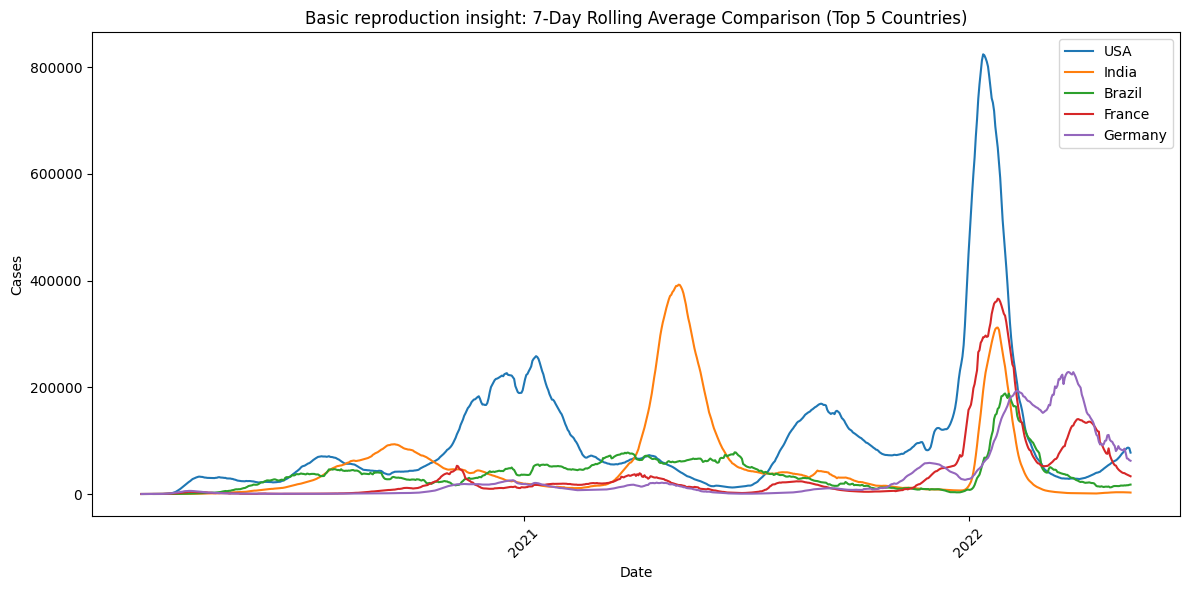

In [49]:
# compute basic reproduction insight (comparison).
# ============================


df.index = pd.to_datetime(df.index)

# Top 5 countries by cumulative cases
top_countries = (
    df.groupby('country')['cumulative_total_cases']
    .max()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(12,6))

for country in top_countries:

    country_data = (
        df[df['country'] == country]
        .copy()
    )

   
    country_data.index = pd.to_datetime(
        country_data.index
    )

    # 7-day rolling average
    country_data['rolling_avg'] = (
        country_data['daily_new_cases']
        .rolling(window=7)
        .mean()
    )

    plt.plot(
        country_data.index,  
        country_data['rolling_avg'],
        label=country
    )

plt.title(
    'Basic reproduction insight: 7-Day Rolling Average Comparison (Top 5 Countries)'
)
plt.xlabel('Date')
plt.ylabel('Cases')

# Cleaner yearly labels
plt.gca().xaxis.set_major_locator(
    mdates.YearLocator()
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('reproduction_insight_comparison.png', bbox_inches='tight', dpi=300)
plt.show()